---
title: "RBIG rotation-choice studies"
short_title: "02 · Rotation choices"
subtitle: "How the rotation between marginal passes sets the convergence speed — PCA, ICA, random, and Picard for fast RBIG"
description: >
  The rotation in each RBIG layer does not change the destination (N(0,I)) but it
  sets how fast you get there. Data-driven rotations (PCA, ICA, Picard) decorrelate
  in a layer or two; a random rotation still converges — the RBIG guarantee — but
  takes many more. This notebook compares the four on layers-to-converge using the
  total-correlation signal from notebook 01, and introduces Picard as a fast,
  scalable ICA solver.
---

(sec-nb-rbig-02)=
# 02 — Rotation-choice studies

Every RBIG layer ends in a rotation (Part 2). Notebook 00 used PCA throughout, but
the rotation is a real design choice — and a consequential one. It does **not**
change *where* RBIG converges (any generic rotation reaches $\mathcal{N}(0,I)$,
the Laparra et al. guarantee {cite}`laparra2011rbig`) but it sets **how fast**: a
rotation that lands the data on informative axes lets the next marginal pass
remove more dependence. We measure "fast" with the convergence yardstick of
[notebook 01](01_convergence_stopping.ipynb) — the total correlation per layer —
and compare the four rotations `rbig` provides.

**What you will see**

- **PCA, ICA, Picard** drive the total correlation to zero in **one layer** on
  correlated data; a **random** rotation takes many.
- Random still converges — the RBIG guarantee — just slowly; *any* generic
  rotation works, which is why random is a valid fit-free default.
- **Picard** {cite}`ablin2018faster` as a fast, scalable ICA solver — the
  practical choice when you want ICA-quality rotations in higher dimensions.

In [1]:
import warnings

warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import numpy as np

import rbig
from _style import style_ax

rng = np.random.default_rng(0)

# Correlated, near-Gaussian 4-D data: total correlation is reliably estimated here
# (notebook 01), positive, and large enough that the rotation choice clearly matters.
n = 3000
zsrc = rng.standard_normal((n, 4))
mix = np.array([[1, .8, .6, .4], [0, 1, .7, .5], [0, 0, 1, .6], [0, 0, 0, 1]], float)
X = zsrc @ mix.T
X = (X - X.mean(0)) / X.std(0)
print(f"initial total correlation = {float(rbig.total_correlation(X)):.3f} nats")

initial total correlation = 0.820 nats


## 1. Rotation choice sets the convergence speed

We run a short RBIG loop with each rotation and record the total correlation after
every layer (the lower, the more independent — convergence). `rbig` provides
`PCARotation`, `ICARotation`, `RandomRotation`, and `PicardRotation`; we drop each
into the same `marginal → rotate` loop.

layers to drive |TC| < 0.02:
  PCA    : 1
  ICA    : 1
  Picard : 1
  random : >12


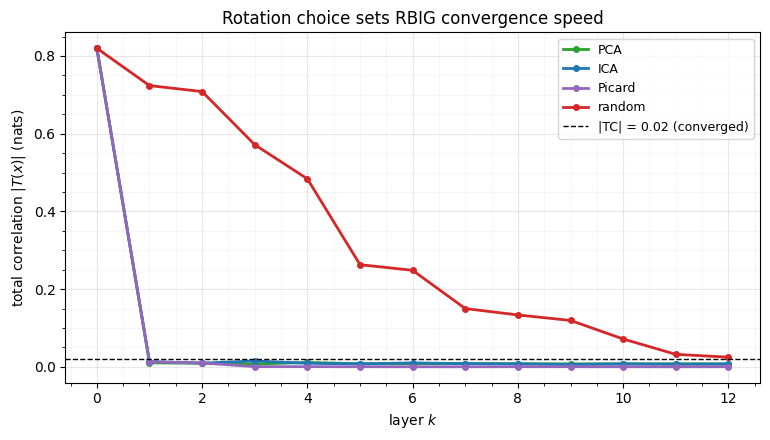

In [2]:
def tc_per_layer(rotation, n_layers=12, seed=0):
    """Total correlation after each RBIG layer, for a given rotation."""
    A = X.copy()
    tc = [float(rbig.total_correlation(A))]
    for k in range(n_layers):
        A = rbig.MarginalGaussianize().fit(A).transform(A)
        rot = {
            "PCA": rbig.PCARotation(whiten=False),
            "ICA": rbig.ICARotation(random_state=seed),
            "random": rbig.RandomRotation(random_state=seed + k),
            "Picard": rbig.PicardRotation(random_state=seed),
        }[rotation]
        A = rot.fit(A).transform(A)
        tc.append(float(rbig.total_correlation(A)))
    return np.abs(np.array(tc))

curves = {r: tc_per_layer(r) for r in ["PCA", "ICA", "Picard", "random"]}
print("layers to drive |TC| < 0.02:")
for r, v in curves.items():
    hit = next((i for i, x in enumerate(v) if x < 0.02), None)
    print(f"  {r:7s}: {hit if hit is not None else '>12'}")

fig, ax = plt.subplots(figsize=(7.8, 4.5))
colors = {"PCA": "tab:green", "ICA": "tab:blue", "Picard": "tab:purple", "random": "tab:red"}
for r, v in curves.items():
    ax.plot(v, "o-", color=colors[r], lw=2, ms=4, label=r)
ax.axhline(0.02, color="k", lw=1, ls="--", label="|TC| = 0.02 (converged)")
ax.set(title="Rotation choice sets RBIG convergence speed",
       xlabel="layer $k$", ylabel="total correlation $|T(x)|$ (nats)")
ax.legend(fontsize=9); style_ax(ax)
fig.tight_layout()

**Data-driven rotations win.** PCA, ICA, and Picard collapse the total correlation
in a *single* layer — they each find axes aligned with the data's structure, so
the next marginal pass removes essentially all the dependence at once. The
**random** rotation, blind to that structure, chips away slowly. Same destination,
very different speed.

## 2. Random still converges — the RBIG guarantee

The slow red curve is not a failure. The theoretical heart of RBIG is that *any*
generic (e.g. Haar-random) rotation drives the distribution to $\mathcal{N}(0,I)$:
each marginal pass can only reduce the total correlation, and a random rotation
keeps re-exposing reducible structure. It just needs more layers. We extend it to
confirm it gets there.

random rotation reaches |TC| < 0.02 at layer 14 (vs 1 for PCA/ICA/Picard)


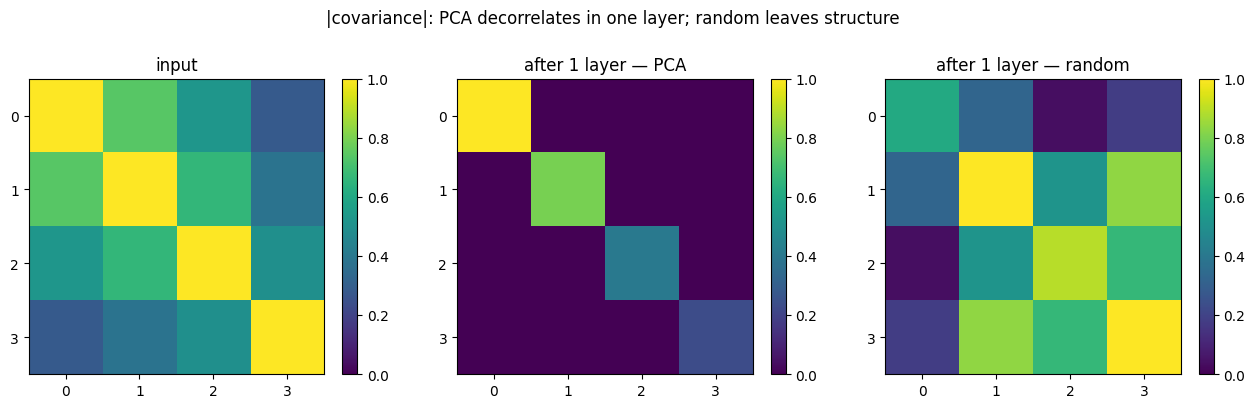

In [3]:
rand_long = tc_per_layer("random", n_layers=20)
reached = next((i for i, x in enumerate(rand_long) if x < 0.02), None)
print(f"random rotation reaches |TC| < 0.02 at layer {reached} "
      f"(vs 1 for PCA/ICA/Picard)")

# Geometry: covariance after ONE layer — PCA decorrelates, random does not.
def one_layer(rotation, seed=0):
    A = rbig.MarginalGaussianize().fit(X).transform(X)
    rot = (rbig.PCARotation(whiten=False) if rotation == "PCA"
           else rbig.RandomRotation(random_state=seed))
    return rot.fit(A).transform(A)

fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
for ax, (M, t) in zip(
    axes,
    [(np.cov(X.T), "input"),
     (np.cov(one_layer("PCA").T), "after 1 layer — PCA"),
     (np.cov(one_layer("random").T), "after 1 layer — random")],
):
    im = ax.imshow(np.abs(M), cmap="viridis", vmin=0, vmax=1)
    ax.set(title=t, xticks=range(4), yticks=range(4))
    fig.colorbar(im, ax=ax, fraction=0.046)
fig.suptitle("|covariance|: PCA decorrelates in one layer; random leaves structure", y=1.03)
fig.tight_layout()

After a single layer PCA's output covariance is diagonal (off-diagonals gone),
while the random rotation's still carries large off-diagonal dependence for the
next pass to handle. So random is a perfectly valid, fit-free default — robust and
assumption-light — you simply pay for it in depth.

## 3. Picard — a fast, scalable ICA for RBIG

PCA only removes *linear* correlation; **ICA** goes further, rotating onto
maximally **non-Gaussian** (independent) axes {cite}`hyvarinen2000ica`, which is
the better target when the data is a mix of non-Gaussian sources. Classic FastICA
can be slow and finicky to converge in high dimensions. **Picard**
{cite}`ablin2018faster` is a preconditioned quasi-Newton solver on the orthogonal
manifold that optimises the same ICA objective far more robustly — the practical
choice for ICA-based RBIG at scale. Here, on low-dimensional data, it matches
ICA's one-layer convergence.

In [4]:
import time

Xg = rbig.MarginalGaussianize().fit(X).transform(X)
for name, R in [("ICA   ", rbig.ICARotation(random_state=0)),
                ("Picard", rbig.PicardRotation(random_state=0))]:
    t0 = time.time()
    R.fit(Xg)
    dt = 1000 * (time.time() - t0)
    print(f"{name}: single-fit {dt:5.1f} ms, "
          f"|TC| after 1 layer = {abs(float(rbig.total_correlation(R.transform(Xg)))):.4f}")

print("\nICA and Picard both converge in one layer here; Picard's quasi-Newton "
      "solver is the one that keeps converging reliably as the dimension grows.")

ICA   : single-fit   7.0 ms, |TC| after 1 layer = 0.0132
Picard: single-fit   9.9 ms, |TC| after 1 layer = 0.0129

ICA and Picard both converge in one layer here; Picard's quasi-Newton solver is the one that keeps converging reliably as the dimension grows.


On this small problem ICA and Picard are neck-and-neck — both reach independence
in one layer and take a few milliseconds. The reason to reach for Picard is
**dimension**: its second-order updates converge in far fewer iterations than
FastICA's fixed-point steps as $d$ grows, so it is the rotation of choice when you
want ICA-quality Gaussianization on high-dimensional data without the fitting cost
blowing up.

## Recap

| rotation | finds | converges | cost | use when |
|---|---|---|---|---|
| **PCA** | variance axes (linear decorrelation) | ~1 layer (Gaussian-ish data) | cheap | scales differ; near-Gaussian dependence |
| **ICA** | non-Gaussian / independent axes | ~1 layer | moderate | mixed non-Gaussian sources |
| **Picard** | same ICA objective, quasi-Newton | ~1 layer | moderate, **scales well** | ICA quality in high $d$ |
| **random** | nothing (Haar) | many layers | free (no fit) | robust fit-free default |

All reach $\mathcal{N}(0,I)$; the choice trades fitting cost against depth. The
convergence signal of notebook 01 is the yardstick that makes the trade-off
measurable.

**Next up.** One practical wrinkle remains: the marginal step relies on the
empirical CDF, which is undefined past the data's range and clips the tails to
$\pm\infty$ under $\Phi^{-1}$. [03 — Boundary issues & support
extension](03_boundary_support.ipynb) handles tail behaviour, support extension,
and dequantising discrete inputs — the last piece before Part 4 turns RBIG into a
*trainable* parametric flow (where the RBIG warm-start lives).